In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

data_path = "melb_data_cleaned.csv"
df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9611 entries, 0 to 9610
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      9611 non-null   str    
 1   Rooms       9611 non-null   int64  
 2   Type        9611 non-null   str    
 3   Price       9611 non-null   float64
 4   Date        9611 non-null   str    
 5   Distance    9611 non-null   float64
 6   Bedroom2    9611 non-null   int64  
 7   Bathroom    9611 non-null   int64  
 8   Car         9611 non-null   int64  
 9   Landsize    9611 non-null   float64
 10  Lattitude   9611 non-null   float64
 11  Longtitude  9611 non-null   float64
 12  Regionname  9611 non-null   str    
 13  year        9611 non-null   int64  
 14  month       9611 non-null   int64  
 15  Type_h      9611 non-null   bool   
 16  Type_t      9611 non-null   bool   
 17  Type_u      9611 non-null   bool   
 18  Region_EM   9611 non-null   bool   
 19  Region_NM   9611 non-null   bool   
 2

In [51]:
# Features
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Suburb",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"]

target = "log_price"
X = df[features]
y = df[target]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(random_state=42)}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_metric = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"}

results = []
for name, model in models.items():
    if name in ["Linear Regression", "Ridge", "Lasso"]:
        pipeline = Pipeline([
            ("encoder", TargetEncoder(cols=["Suburb"])),
            ("scaler", StandardScaler()),
            ("model", model)])
    else:
        pipeline = Pipeline([
            ("encoder", TargetEncoder(cols=["Suburb"])),
            ("model", model)])

    scores = cross_validate(pipeline, X_train, y_train, cv=kf, scoring=scoring_metric)

    results.append({
        "Model": name,
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean()})



results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")


,Model,MAE,RMSE,R2
3,Random Forest,0.147846,0.196910,0.818432
1,Ridge,0.187186,0.240997,0.727862
0,Linear Regression,0.187187,0.240997,0.727862
2,Lasso,0.188895,0.244107,0.720786


### Nhận xét:
Random forest có kết quả khả quan nhất<br>
Ta chọn random forest, sau đó, xem sự khác biệt giữa khi có và không có Suburb



In [69]:
#Khi không có Suburb
# Features
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"]

target = "log_price"
X = df[features]
y = df[target]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit random forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=8, min_samples_split=20, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán
y_pred = rf.predict(X_test)

# Đưa log_price về Price
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

# Metrics
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2 = r2_score(y_test_price, y_pred_price)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.2f}")

# Train R2:
y_train_pred = rf.predict(X_train)
y_train_price = np.exp(y_train)
y_train_pred_price = np.exp(y_train_pred)

print("Train R2:", r2_score(y_train_price, y_train_pred_price))
print("Test R2:", r2)


MAE: 181,520.77
RMSE: 272,800.28
R2 Score: 0.73
Train R2: 0.7953099250701212
Test R2: 0.7315555738645704


In [70]:
#Khi có Suburb
# Features
features = [
    "Rooms", "Bathroom", "Car", "Landsize", "Distance",
    "Suburb",
    "Type_h", "Type_t", "Type_u",
    "Region_NM", "Region_WM", "Region_SM", "Region_EM", "Region_SEM"]

target = "log_price"
X = df[features]
y = df[target]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#encode suburb
encoder = TargetEncoder(cols=["Suburb"])

X_train = encoder.fit_transform(X_train, y_train)
X_test = encoder.transform(X_test)

# Fit random forest
rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=8, min_samples_split=20, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = rf.predict(X_test)

# Đưa log_price về Price
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

# Metrics
mae = mean_absolute_error(y_test_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2 = r2_score(y_test_price, y_pred_price)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2 Score: {r2:.2f}")

# Train R2:
train_pred = rf.predict(X_train)
y_train_price = np.exp(y_train)
train_pred_price = np.exp(train_pred)

print("Train R2:", r2_score(y_train_price, train_pred_price))
print("Test R2:", r2)

MAE: 170,452.97
RMSE: 256,781.89
R2 Score: 0.76
Train R2: 0.8197282131124347
Test R2: 0.7621552510499292


### Nhận xét:
So sánh thấy có Suburb giúp cải thiện các metric<br>
R2 của Train và Test tăng đều<br>
Xem xét khoảng cách giữa Train R2 và Test R2:
- Không có Suburb: 0.795 − 0.731 = 0.064
- Có Suburb: 0.819 − 0.762 = 0.057

Sai khác là không quá lớn. Không có dấu hiệu overfit.

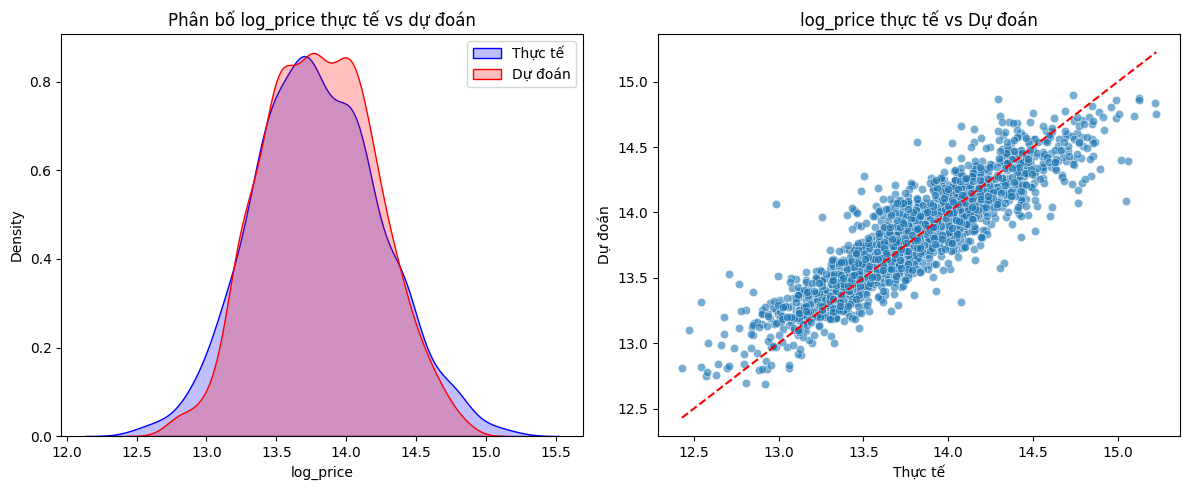

In [ ]:
# 1. Trực quan hóa kết quả (Ta giữ log_price để tiện cho việc trực quan hóa)
plt.figure(figsize=(12, 5))

# Biểu đồ phân bố
plt.subplot(1, 2, 1)
sns.kdeplot(y_test, label="Thực tế", fill=True, color="blue")
sns.kdeplot(y_pred, label="Dự đoán", fill=True, color="red")
plt.title("Phân bố log_price thực tế vs dự đoán")
plt.xlabel("log_price")
plt.legend()

# Biểu đồ scatter
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("log_price thực tế vs Dự đoán")
plt.xlabel("Thực tế")
plt.ylabel("Dự đoán")
plt.tight_layout()
plt.show()

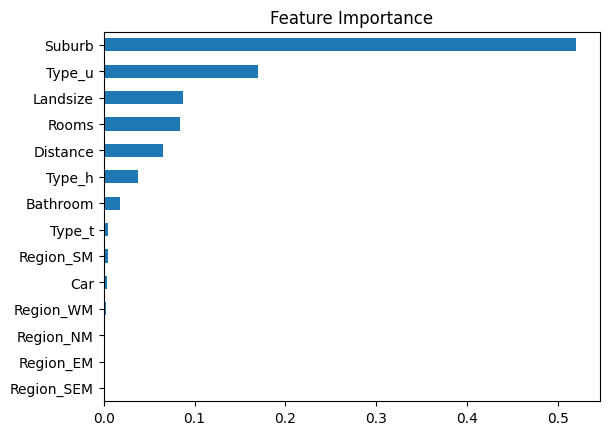

In [72]:
# 2. Important features:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

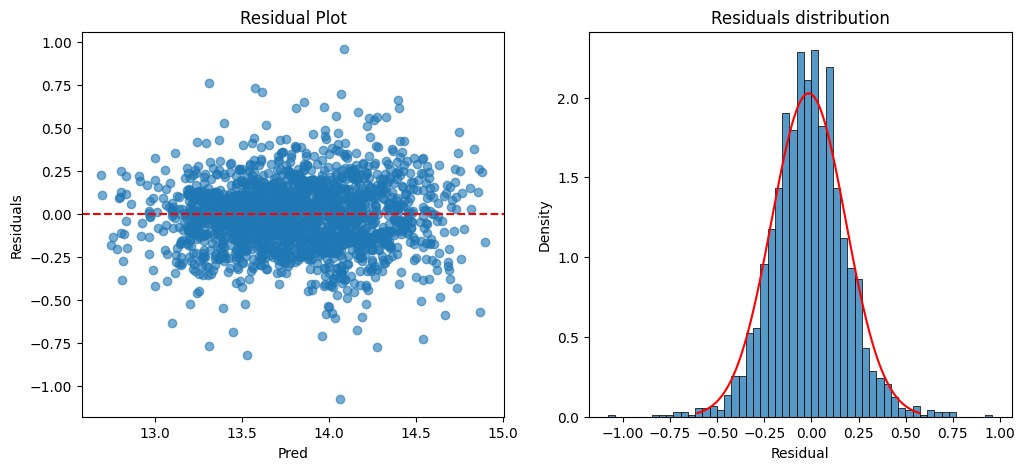

In [73]:
# 3. Biểu đồ phần dư
residuals = y_test - y_pred

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Pred")
plt.ylabel("Residuals")
plt.title("Residual Plot")

# Phân bố phần dư
plt.subplot(1, 2, 2)
sns.histplot(residuals, stat="density")
# vẽ đường normal
mean = np.mean(residuals)
std = np.std(residuals)
x = np.linspace(mean - 3*std, mean + 3*std, 100)
y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
plt.plot(x, y, color='r')
plt.title("Residuals distribution")
plt.xlabel("Residual")
plt.show()

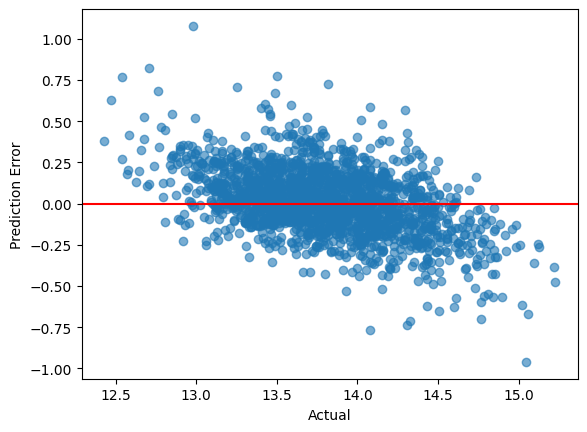

In [74]:
# 4. Prediction error plot
plt.scatter(y_test, y_pred - y_test, alpha=0.6)
plt.axhline(0, color="red")
plt.xlabel("Actual")
plt.ylabel("Prediction Error")
plt.show()

# Nhận xét:
- Nhìn vào các metric và phân bố dự đoán - thực tế, ta thấy mô hình có độ chính xác tương đối cao. Tuy nhiên, phân phối dự đoán bị kéo về trung bình, hẹp hơn so với phân bố thật.
- Nhận thấy yếu tố ảnh hưởng lớn đến giá trị của BĐS là khu vực địa lý. Ở bước 3, ta đã nhìn ra xu hướng đó
- Residual phân bố ngẫu nhiên quanh giá trị 0, theo phân phối chuẩn. Chỉ ra mô hình fit với data
- Một điểm đáng chú ý của Pred Error plot: có xu hướng âm (Nâng giá thấp, hạ giá cao) hay chính là đang kéo về hướng mean.